In [1]:
# Importar Librerías

import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
BASE_DIR = Path().resolve().parent
ruta_datos = BASE_DIR / 'data' / 'Dataset_Smart_Farming_base.csv'

In [3]:
# Carga de datos
df = pd.read_csv(ruta_datos)
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status,N,P,K
0,FARM0001,North India,Wheat,35.95,5.99,17.456436,75.62,76.406275,7.27,NaN,...,4408.07,SNS-2026-0001,2024-03-19,14.970941,82.997689,0.63,Mild,11,60,23
1,FARM0002,South USA,Soybean,19.74,7.24,30.275671,89.91,60.899686,5.67,Sprinkler,...,5389.98,SNS-2026-0002,2024-04-21,16.613022,70.869009,0.58,NaN,136,36,20
2,FARM0003,South USA,Wheat,29.32,7.16,27.453712,265.43,68.954600,8.23,Drip,...,2931.16,SNS-2026-0003,2024-02-28,19.503156,79.068206,0.80,Mild,23,45,23
3,FARM0004,Central USA,Maize,133.00,6.03,34.033155,212.01,69.238224,5.03,Sprinkler,...,4227.80,SNS-2026-0004,2024-05-14,31.071298,85.519998,0.44,NaN,113,6,52
4,FARM0005,Central USA,Cotton,19.37,5.92,33.685737,269.09,54.595901,7.93,NaN,...,4979.96,SNS-2026-0005,2024-04-13,16.568540,81.691720,0.84,Severe,101,92,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,FARM0496,Central USA,Rice,42.85,6.70,31.073145,52.35,80.614607,7.25,Manual,...,4251.40,SNS-2026-2496,2024-05-08,30.386623,76.147700,0.59,Mild,58,73,16
2496,FARM0497,North India,Soybean,34.22,6.75,17.493631,256.23,44.890922,5.78,NaN,...,3708.54,SNS-2026-2497,2024-01-19,18.832748,75.736924,0.85,Severe,129,43,16
2497,FARM0498,North India,Cotton,15.93,5.72,17.553392,288.96,58.852243,7.69,Drip,...,2604.41,SNS-2026-2498,2024-04-20,23.262016,81.992230,0.71,Mild,105,74,45
2498,FARM0499,Central USA,Soybean,38.61,6.20,16.995694,279.06,72.951453,9.60,Drip,...,2586.36,SNS-2026-2499,2024-03-02,19.764989,84.426869,0.77,Severe,126,37,21


In [4]:
# FILTRO: Para que El Agrónomo aprenda, eliminamos las filas donde NO sabemos qué fertilizante se usó
df_agronomo = df.dropna(subset=['fertilizer_type']).copy()

In [5]:
# SEPARACIÓN DE VARIABLES
# 'y' es la recomendación del experto (El tipo de fertilizante)
y_agronomo = df_agronomo['fertilizer_type']

# 'X' son los exámenes de suelo que lee el Agrónomo
# Seleccionamos variables agronómicas clave
columnas_agronomicas = ['N', 'P', 'K', 'soil_pH', 'soil_moisture_%', 'crop_type', 'region']
X_agronomo = df_agronomo[columnas_agronomicas]

In [7]:
print("\nTipos de fertilizantes a predecir:")
print(y_agronomo.value_counts())


Tipos de fertilizantes a predecir:
fertilizer_type
Inorganic    835
Mixed        835
Organic      830
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [9]:
# Dividimos Train/Test (70/30)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_agronomo, y_agronomo, test_size=0.3, random_state=42, stratify=y_agronomo
)

# Definimos transformaciones específicas para El Agrónomo
variables_categoricas = ['region', 'crop_type']
variables_numericas = ['N', 'P', 'K', 'soil_pH', 'soil_moisture_%']

In [10]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), variables_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas)
])

In [11]:
# Aplicamos la "Licuadora"
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)
print(" Datos procesados correctamente.")

 Datos procesados correctamente.


In [12]:
# Entrenando modelo con randomm forest
modelo_agronomo = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_agronomo.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
# evaluar resultados
y_pred = modelo_agronomo.predict(X_test_processed)

precision = accuracy_score(y_test, y_pred)
print(f" Precisión Global (Accuracy): {precision * 100:.2f}%\n")

 Precisión Global (Accuracy): 81.33%



--- REPORTE DETALLADO POR FERTILIZANTE ---
              precision    recall  f1-score   support

   Inorganic       0.83      0.84      0.84       251
       Mixed       0.81      0.78      0.79       250
     Organic       0.81      0.82      0.81       249

    accuracy                           0.81       750
   macro avg       0.81      0.81      0.81       750
weighted avg       0.81      0.81      0.81       750



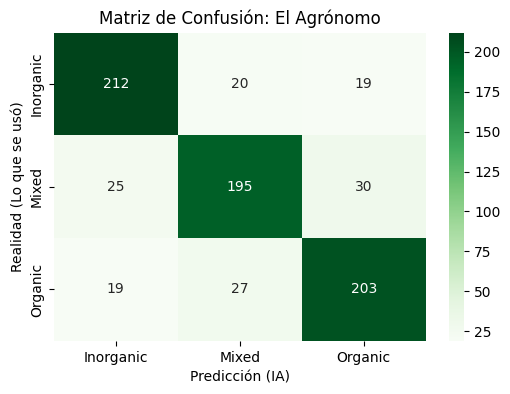

In [14]:
print("--- REPORTE DETALLADO POR FERTILIZANTE ---")
print(classification_report(y_test, y_pred))

# Gráfico de Confusión (En tonos verdes para diferenciarlo)
plt.figure(figsize=(6, 4))
matriz_conf = confusion_matrix(y_test, y_pred)
etiquetas = sorted(y_test.unique())
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Greens', xticklabels=etiquetas, yticklabels=etiquetas)
plt.title('Matriz de Confusión: El Agrónomo')
plt.ylabel('Realidad (Lo que se usó)')
plt.xlabel('Predicción (IA)')
plt.show()

In [18]:
# Exportando
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(modelo_agronomo, MODELS_DIR / 'agronomo_rf.pkl')
joblib.dump(preprocessor, MODELS_DIR / 'preprocesador_agronomo.pkl')

print(" Archivos .pkl creados con éxito")

 Archivos .pkl creados con éxito


In [15]:
# NUEVO: AUDITORÍA DE PREDICCIONES (TEST)

print("\nGenerando archivo de auditoría: Auditoria_Agronomo_Test.csv")

# Creamos el DataFrame de revisión
df_audit_agronomo = X_test_raw.copy()
df_audit_agronomo['FERTILIZANTE_REAL'] = y_test
df_audit_agronomo['PREDICCION_MODELO'] = y_pred

# Exportamos los primeros 500 registros
ruta_auditoria = BASE_DIR / 'data' / 'Auditoria_Agronomo_Test_500.csv'
df_audit_agronomo.head(500).to_csv(ruta_auditoria, index=False, encoding='utf-8')
print(f"Archivo exportado en: {ruta_auditoria}")


Generando archivo de auditoría: Auditoria_Agronomo_Test.csv
Archivo exportado en: C:\Users\fabio\PycharmProjects\AgroSmartTech_MLOps\data\Auditoria_Agronomo_Test_500.csv
